
PERFORMANCE STATISTICS FOR MARKET NEUTRAL
Daily annualized sharpe: 1.526554269966379
Average annual returns: 14.496722334170729%
Total returns: 144.79464331391952%
Max drawdown: -20.917597058487193%
Stressed period return during Covid19:  -13.609529615513896%
Stressed period return during Dec18:  3.5765779786037366%
Stressed period return during Fall2015:  2.147954666945533%
Stressed period return during Oct14:  0.4763952234596674%
Stressed period return during Aug2013:  -0.11368183480925491%


PERFORMANCE STATISTICS FOR SECTOR NEUTRAL
Daily annualized sharpe: 1.7791742805753752
Average annual returns: 15.226439863974802%
Total returns: 152.08313149851023%
Max drawdown: -15.52335198506758%
Stressed period return during Covid19:  -11.462535953198696%
Stressed period return during Dec18:  3.3098623037572614%
Stressed period return during Fall2015:  1.8041572233077257%
Stressed period return during Oct14:  1.0406147335733473%
Stressed period return during Aug2013:  -0.10501250844735996%


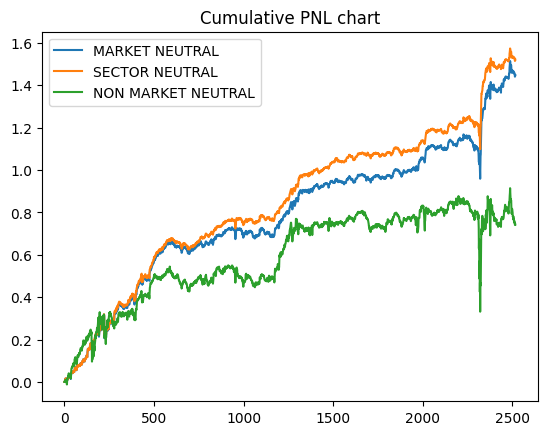

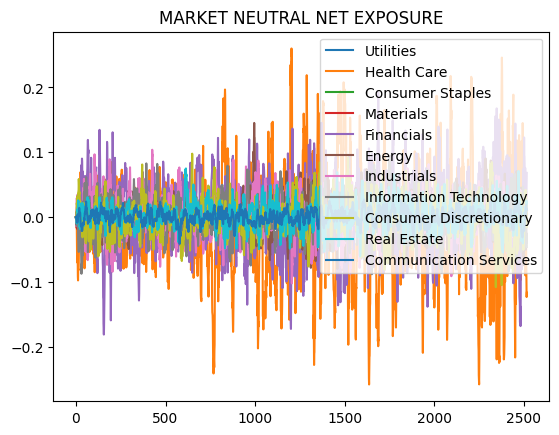

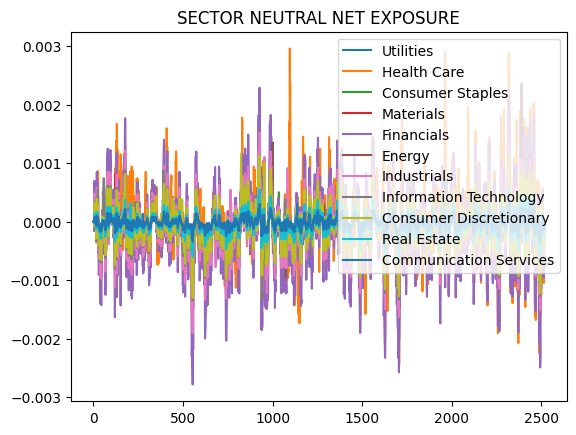

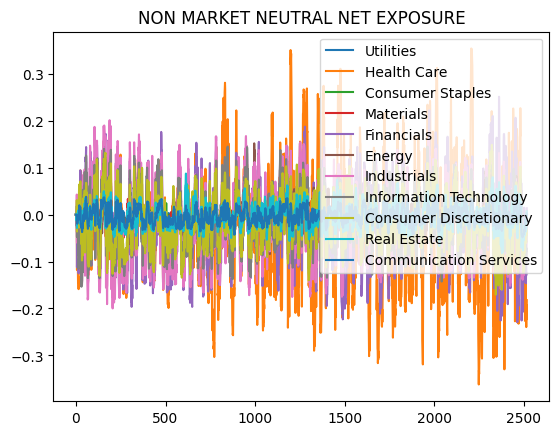

In [1]:
#GENERAL INSTRUCTIONS:
#1.  PUT ALL INPUT CSV DATA FILES IN THE SAME DIRECTORY
#2.  START PYTHON AND CHANGE WORKING DIRECTORY TO DIRECTORY FROM STEP 1
#3.  COPY AND PASTE THIS ENTIRE FILE AND PASTE INTO PYTHON INTERPRETER, AND PRESS <ENTER>
#4.  WAIT FOR AROUND 30 SECONDS.  SOME CHARTS MIGHT LOOK LIKE THEY HAVE CRASHED DURING COMPUTATION, BUT THEY SHOULD UNFREEZE IN <1 MINUTE
#5.  IF ANY ERRORS, CHECK FIRST TO SEE IF YOU ACCIDENTALLY INTRODUCED ANY EXTRA TABS OR SPACES WHEN COPYING AND PASTING.  IF NOT, EMAIL BENJAMINEE@SMU.EDU.SG
#6.  HERE IS GENERAL OUTLINE OF REST OF THIS FILE:
#7.  "PORTFOLIODIAGNOSTICS" IS A FUNCTION THAT TAKES IN A PORTFOLIO DATAFRAME AND COMPUTES NET EXPOSURES BY SECTORS
#8.  "PNLPERFORMANCE" IS A FUNCTION THAT TAKES IN A PNL SERIES AND COMPUTES SHARPE, RETURN, DRAWDOWN, ETC
#9.  ALL SCRIPT AFTER THESE 2 FUNCTIONS WOULD BE THE ACTUAL MEAN REVERSION STRATEGY

import pandas as pd;
import numpy as np;
import os;
import matplotlib.pyplot as plt;

os.chdir("/Users/ju/Projects/00_SMU/mqf_practice/QF621_Quant_Trading_Strats/data")


#Utility method takes in daily % pnl vector and computes portfolio diagnostics
#daily % pnl is inputed as a dataframe, with date as index and corresponding pnl for that date as the value
def portfolioDiagnostics(signal_df, label):
    #NET SECTOR EXPOSURES
    plt.figure();
    sector_df = pd.read_csv("sector.csv", on_bad_lines='skip')
    d = sector_df.set_index('ticker').to_dict()
    signal_df2 = signal_df.copy(deep=True)
    signal_df2.columns = signal_df2.columns.to_series().map(d['sector'])
    uniquesector = list(set(signal_df2.columns))
    for tsector in uniquesector:
        if (str(tsector)=='nan'):
            continue;
        tmean = signal_df2.loc[:, tsector].sum(axis=1)
        tmean[~np.isfinite(tmean)] = 0
        plt.plot(tmean.values, label=tsector)
        plt.legend();
        plt.title(label+" NET EXPOSURE")
    plt.show(block=False)
    return


#Utility method takes in daily % pnl vector and computes pnl diagnostics
#daily % pnl is inputed as a dataframe, with date as index and corresponding pnl for that date as the value
def pnlPerformance(pnl, label):
    cumpnl = pnl.cumsum(skipna = True)
    import matplotlib.pyplot as plt
    import numpy as np
    sharpe = pnl.mean()/np.std(pnl)
    sharpe = sharpe*np.sqrt(252)
    print("")
    print ("PERFORMANCE STATISTICS FOR "+label);
    print("Daily annualized sharpe: "+str(sharpe))
    print ("Average annual returns: "+str(pnl.mean()*252*100)+"%")
    print ("Total returns: "+str(pnl.sum()*100)+"%");
    highwatermark_df = cumpnl.cummax();
    drawdown_df = cumpnl - highwatermark_df;
    maxdrawdown = drawdown_df.min();
    print ("Max drawdown: "+str(maxdrawdown*100)+"%");
    plt.plot(cumpnl.values, label = label);
    plt.legend();
    plt.title("Cumulative PNL chart")
    #HERE, we compute performance during 'stressed' historical periods
    stressedmarkets = dict()
    stressedmarkets["Covid19"] = (20200301, 20200317);          #Market crash 1H March 2020
    stressedmarkets["Dec18"] = (20181215, 20181231);            #Market crash last 2 weeks
    stressedmarkets["Fall2015"] = (20150701, 20150901);         #Taper tantrum / EU debt crisis.  24 Aug 2015 was "BlackMonday" for Asian, EU and US markets
    stressedmarkets["Oct14"] = (20141001, 20141031);            #Treasury flash crash on 15 Oct 2014
    stressedmarkets["Aug2013"] = (20130820, 20130825);          #Flash freeze on 22 Aug 2013

    for tkey in stressedmarkets.keys():
        mask = pnl.index.to_series().between(stressedmarkets[tkey][0], stressedmarkets[tkey][1])
        print("Stressed period return during "+tkey+":  "+str(pnl[mask].sum()*100)+"%")
    print("===========================")
    print("")


#=======ACTUAL STRATEGY SCRIPT STARTS HERE============================#

russell_df = pd.read_csv("russell2000pvdata.csv", on_bad_lines='skip')
vars = ['open', 'high', 'low', 'close', 'volume']
rawdata = {}
reversiontimehorizon = 10           #NUMBER OF TRADING DAYS TO COMPUTE MEAN REVERSION OVER.  THIS IS A PARAMETER FOR FITTING
universesize = 2000                 #SIZE OF PORTFOLIO IN NUMBER OF STOCKS.  IF THIS IS MORE THAN 2000, IT WILL GENERALLY JUST BE CAPPED AT 2000 SINCE BASE UNIVERSE IS RUSSELL 2000
maxindividualweight = 0.01          #MAXIMUM FRACTION A SINGLE POSITION CAN TAKE UP OF ENTIRE PORTFOLIO.  0.01 MEANS 1%.  i.e. if you have a portfolio of $100 million, max single position size is $1 million

#MARKET NEUTRAL STRATEGY BASED ON N DAY REVERSION, BASE UNIVERSE IS STOCKS IN RUSSELL 2000
for tvar in vars:
    rawdata[tvar] = russell_df.loc[:, ['tickerid', 'ticker', 'date', tvar]]
    rawdata[tvar] = rawdata[tvar].pivot(index = 'date', columns = 'ticker', values = tvar)
    rawdata[tvar] = rawdata[tvar].iloc[:, :universesize]

return_df = (rawdata['close'] / rawdata['close'].shift(1)) - 1
signal_df = -return_df.rolling(reversiontimehorizon, min_periods = 3).mean()
signal_df = signal_df.subtract(signal_df.mean(axis=1), axis='index')
signal_df = signal_df.divide(signal_df.abs().sum(axis=1), axis='index')
signal_df = signal_df.shift(1)                                              #TO AVOID FORWARD BIAS.  WE USE YESTERDAY'S INFORMATION TO EXECUTE AT TODAY'S CLOSE PRICES
for i in range(3):
    signal_df[signal_df > maxindividualweight] = maxindividualweight
    signal_df[signal_df < -maxindividualweight] = -maxindividualweight
    signal_df = signal_df.subtract(signal_df.mean(axis=1), axis='index')
    signal_df = signal_df.divide(signal_df.abs().sum(axis=1), axis='index')
pnl_df = signal_df * return_df.shift(-1)                                    #BASED ON YESTERDAY'S INFORMATION, WE EXECUTE AT TODAY'S CLOSE PRICES AND COMPUTE OUR PNL BASED ON TOMORROW'S RETURN
pnl = pnl_df.sum(axis=1)
pnlPerformance(pnl, "MARKET NEUTRAL")
marketneutralportfolio = signal_df.copy(deep=True)


#SECTOR NEUTRAL STRATEGY BASED ON N DAY REVERSION, ALL STOCKS IN RUSSELL 2000
sector_df = pd.read_csv("sector.csv", on_bad_lines='skip')
d = sector_df.set_index('ticker').to_dict()
signal_df2 = signal_df.copy(deep=True)                                      #WE JUST REUSE THE PORTFOLIO WEIGHTS FROM PREVIOUS STRATEGY, SINCE WE ARE JUST NEUTRALIZING DIFFERENTLY HERE
signal_df2.columns = signal_df2.columns.to_series().map(d['sector'])
uniquesector = list(set(signal_df2.columns))
for tsector in uniquesector:
    if (str(tsector)=='nan'):
        continue;
    tmean = signal_df2.loc[:, tsector].mean(axis=1)
    tmean[~np.isfinite(tmean)] = 0
    signal_df2.loc[:, tsector] = signal_df2.loc[:, tsector].subtract(tmean, axis='index');
signal_df = pd.DataFrame(data = signal_df2.values, index = signal_df.index, columns = signal_df.columns)
signal_df = signal_df.divide(signal_df.abs().sum(axis=1), axis='index')
for i in range(3):
    signal_df[signal_df > maxindividualweight] = maxindividualweight
    signal_df[signal_df < -maxindividualweight] = -maxindividualweight
    signal_df = signal_df.subtract(signal_df.mean(axis=1), axis='index')
    signal_df = signal_df.divide(signal_df.abs().sum(axis=1), axis='index')
pnl_df = signal_df * return_df.shift(-1)
pnl = pnl_df.sum(axis=1)
pnlPerformance(pnl, "SECTOR NEUTRAL")
sectorneutralportfolio = signal_df.copy(deep=True)


#NON MARKET NEUTRAL STRATEGY BASED ON N DAY REVERSION, BASE UNIVERSE IS STOCKS IN RUSSELL 2000
for tvar in vars:
    rawdata[tvar] = russell_df.loc[:, ['tickerid', 'ticker', 'date', tvar]]
    rawdata[tvar] = rawdata[tvar].pivot(index = 'date', columns = 'ticker', values = tvar)
    rawdata[tvar] = rawdata[tvar].iloc[:, :universesize]

return_df = (rawdata['close'] / rawdata['close'].shift(1)) - 1
signal_df = -return_df.rolling(reversiontimehorizon, min_periods = 3).mean()
signal_df = signal_df.divide(signal_df.abs().sum(axis=1), axis='index')
signal_df = signal_df.shift(1)

for i in range(3):
    signal_df[signal_df > maxindividualweight] = maxindividualweight
    signal_df[signal_df < -maxindividualweight] = -maxindividualweight
    signal_df = signal_df.divide(signal_df.abs().sum(axis=1), axis='index')
pnl_df = signal_df * return_df.shift(-1)
pnl = pnl_df.sum(axis=1)
pnlPerformance(pnl, "NON MARKET NEUTRAL")
nonmarketneutralportfolio = signal_df.copy(deep=True)





portfolioDiagnostics(marketneutralportfolio, "MARKET NEUTRAL");
portfolioDiagnostics(sectorneutralportfolio, "SECTOR NEUTRAL");
portfolioDiagnostics(nonmarketneutralportfolio, "NON MARKET NEUTRAL");


plt.show(block = False)










In [2]:
## SIGNAL DATA
marketneutralportfolio
# portfolioDiagnostics(sectorneutralportfolio, "SECTOR NEUTRAL");
# portfolioDiagnostics(nonmarketneutralportfolio, "NON MARKET NEUTRAL");

ticker,AADR,AAN,AAOI,AAON,AAT,AAWW,ABCB,ABEO,ABG,ABM,...,YMAB,YORW,ZEUS,ZGNX,ZIOP,ZIXI,ZNTL,ZUMZ,ZUO,ZYXI
date,,,,,,,,,,,,,,,,,,,,,
20101227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101231,-0.000128,NaN,NaN,0.000201,NaN,0.000515,0.000618,0.001867,-0.001349,0.000255,...,NaN,0.000893,-0.001135,0.000982,0.000476,0.001456,NaN,0.001449,NaN,-0.004379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20201217,0.000347,0.000494,0.000392,0.000520,0.000500,0.000246,-0.000136,0.000076,-0.000836,0.000059,...,0.000160,0.000188,0.000089,0.000922,0.000394,0.000140,0.000244,0.000498,-0.000172,-0.000010
20201218,0.000307,0.000448,0.000177,0.000141,0.000669,0.000466,-0.000153,0.000170,-0.000448,0.000155,...,-0.000035,0.000194,0.000421,0.001049,-0.000215,0.000093,0.000437,0.000454,-0.000134,0.000062
20201221,-0.000024,0.000493,0.000139,0.000012,0.000826,0.000341,-0.000071,0.000058,-0.000039,0.000156,...,-0.000110,0.000106,0.001069,0.000895,-0.000043,-0.000562,0.000151,-0.000003,-0.000556,0.000252


In [3]:
## Market neutral Ticker data
rawdata.keys(), rawdata['close'].head(5), rawdata['close'].tail(5)

(dict_keys(['open', 'high', 'low', 'close', 'volume']),
 ticker         AADR  AAN  AAOI      AAON  AAT       AAWW   ABCB   ABEO  \
 date                                                                     
 20101227  29.590000  NaN   NaN  8.586667  NaN  57.250000  10.92  129.0   
 20101228  29.590000  NaN   NaN  8.524444  NaN  56.500000  10.96  124.5   
 20101229  29.790001  NaN   NaN  8.548148  NaN  56.810001  11.07  123.5   
 20101230  29.730000  NaN   NaN  8.548148  NaN  56.490002  10.74  122.5   
 20101231  29.840000  NaN   NaN  8.358519  NaN  55.830002  10.54  124.0   
 
 ticker          ABG        ABM  ...  YMAB       YORW       ZEUS       ZGNX  \
 date                            ...                                          
 20101227  18.100000  26.760000  ...   NaN  17.730000  27.940001  47.759998   
 20101228  17.820000  26.790001  ...   NaN  17.750000  27.719999  45.119999   
 20101229  18.450001  26.730000  ...   NaN  17.580000  28.469999  44.480000   
 20101230  18.799999  

In [4]:
uniquesector

['Utilities',
 'Health Care',
 'Consumer Staples',
 'Materials',
 nan,
 'Financials',
 'Energy',
 'Industrials',
 'Information Technology',
 'Consumer Discretionary',
 'Real Estate',
 'Communication Services']

In [5]:
signal_df2

ticker,NaN,Consumer Discretionary,Information Technology,Industrials,Real Estate,Industrials,Financials,Health Care,Consumer Discretionary,Industrials,...,Health Care,Utilities,Utilities,Health Care,Health Care,Information Technology,Health Care,Financials,Information Technology,Health Care
date,,,,,,,,,,,,,,,,,,,,,
20101227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101231,-0.000128,NaN,NaN,0.000108,NaN,0.000422,0.000659,0.001842,-0.001410,0.000162,...,NaN,0.000816,-0.001213,0.000957,0.000450,0.001403,NaN,0.001490,NaN,-0.004405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20201217,0.000347,0.000413,0.000506,0.000487,0.000436,0.000212,-0.000217,0.000170,-0.000916,0.000026,...,0.000254,-0.000010,-0.000109,0.001016,0.000488,0.000254,0.000338,0.000418,-0.000058,0.000084
20201218,0.000307,0.000324,0.000291,0.000052,0.000524,0.000377,-0.000248,0.000338,-0.000572,0.000066,...,0.000132,0.000049,0.000276,0.001217,-0.000048,0.000207,0.000604,0.000359,-0.000020,0.000229
20201221,-0.000024,0.000434,0.000329,-0.000095,0.000586,0.000234,-0.000157,0.000267,-0.000099,0.000049,...,0.000099,-0.000026,0.000937,0.001105,0.000167,-0.000372,0.000361,-0.000089,-0.000367,0.000462


In [6]:
tmean.isna().sum()

0

In [7]:
for tvar in vars:
    rawdata[tvar] = russell_df.loc[:, ['tickerid', 'ticker', 'date', tvar]]
    rawdata[tvar] = rawdata[tvar].pivot(index = 'date', columns = 'ticker', values = tvar)
    rawdata[tvar] = rawdata[tvar].iloc[:, :universesize]

return_df = (rawdata['close'] / rawdata['close'].shift(1)) - 1
signal_df = -return_df.rolling(reversiontimehorizon, min_periods = 3).mean()
signal_df = signal_df.divide(signal_df.abs().sum(axis=1), axis='index')
signal_df = signal_df.shift(1)
signal_df.head()

ticker,AADR,AAN,AAOI,AAON,AAT,AAWW,ABCB,ABEO,ABG,ABM,...,YMAB,YORW,ZEUS,ZGNX,ZIOP,ZIXI,ZNTL,ZUMZ,ZUO,ZYXI
date,,,,,,,,,,,,,,,,,,,,,
20101227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101231,-0.000165,NaN,NaN,0.000156,NaN,0.000461,0.000561,0.001777,-0.001354,0.000208,...,NaN,0.000829,-0.001145,0.000916,0.000423,0.001377,NaN,0.00137,NaN,-0.004303


In [8]:
signal_df.abs().sum(axis=1)

date
20101227    0.0
20101228    0.0
20101229    0.0
20101230    0.0
20101231    1.0
           ... 
20201217    1.0
20201218    1.0
20201221    1.0
20201222    1.0
20201223    1.0
Length: 2517, dtype: float64

In [9]:
signal_df.mean(axis=1).tail(20)

date
20201125   -0.000408
20201127   -0.000403
20201130   -0.000454
20201201   -0.000369
20201202   -0.000264
20201203   -0.000283
20201204   -0.000366
20201207   -0.000420
20201208   -0.000407
20201209   -0.000397
20201210   -0.000230
20201211   -0.000313
20201214   -0.000239
20201215   -0.000332
20201216   -0.000394
20201217   -0.000367
20201218   -0.000394
20201221   -0.000218
20201222   -0.000216
20201223   -0.000138
dtype: float64

In [10]:
signal_df[signal_df > maxindividualweight] = maxindividualweight
signal_df[signal_df < -maxindividualweight] = -maxindividualweight
signal_df = signal_df.divide(signal_df.abs().sum(axis=1), axis='index')

In [11]:
signal_df.mean(axis=1).tail(20)

date
20201125   -0.000408
20201127   -0.000403
20201130   -0.000454
20201201   -0.000369
20201202   -0.000264
20201203   -0.000283
20201204   -0.000366
20201207   -0.000420
20201208   -0.000407
20201209   -0.000397
20201210   -0.000230
20201211   -0.000313
20201214   -0.000239
20201215   -0.000332
20201216   -0.000394
20201217   -0.000367
20201218   -0.000394
20201221   -0.000218
20201222   -0.000216
20201223   -0.000138
dtype: float64

In [12]:
signal_df = signal_df.subtract(signal_df.mean(axis=1), axis='index')
signal_df = signal_df.divide(signal_df.abs().sum(axis=1), axis='index')

In [13]:
signal_df

ticker,AADR,AAN,AAOI,AAON,AAT,AAWW,ABCB,ABEO,ABG,ABM,...,YMAB,YORW,ZEUS,ZGNX,ZIOP,ZIXI,ZNTL,ZUMZ,ZUO,ZYXI
date,,,,,,,,,,,,,,,,,,,,,
20101227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20101231,-0.000128,NaN,NaN,0.000201,NaN,0.000515,0.000618,0.001866,-0.001348,0.000255,...,NaN,0.000893,-0.001134,0.000982,0.000476,0.001455,NaN,0.001448,NaN,-0.004374
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20201217,0.000347,0.000494,0.000392,0.000520,0.000500,0.000246,-0.000136,0.000076,-0.000836,0.000059,...,0.000160,0.000188,0.000089,0.000921,0.000394,0.000140,0.000244,0.000498,-0.000172,-0.000010
20201218,0.000307,0.000448,0.000177,0.000141,0.000669,0.000466,-0.000153,0.000170,-0.000448,0.000155,...,-0.000035,0.000194,0.000421,0.001049,-0.000215,0.000093,0.000437,0.000454,-0.000134,0.000062
20201221,-0.000024,0.000493,0.000139,0.000012,0.000826,0.000341,-0.000071,0.000058,-0.000039,0.000156,...,-0.000110,0.000106,0.001069,0.000895,-0.000043,-0.000562,0.000151,-0.000003,-0.000556,0.000252


In [14]:
pnl_df.sum(axis=1).head(20)

date
20101227    0.000000
20101228    0.000000
20101229    0.000000
20101230    0.000000
20101231    0.007236
20110103   -0.001162
20110104    0.002966
20110105   -0.005491
20110106   -0.000404
20110107   -0.000236
20110110   -0.000022
20110111    0.005205
20110112   -0.011007
20110113   -0.000989
20110114   -0.008203
20110118    0.017793
20110119    0.008864
20110120   -0.001233
20110121    0.002969
20110124    0.003352
dtype: float64